### **ACID - PART 4a - Compute background function**

# --- --- ---

### This notebook computes and saves a background function. Part 4b notebook imports the background function and uses it for illumination correction.

### Skeep this notebook if a background function has already been computed and saved.

# --- --- ---

**Author:** Alessandro Ulivi (alessandro.ulivi.89@gmail.com)

**Last update (yyyy/mm/dd):** 2026/02/11


## **---------------------------**

### Import required modules

Run the following cell.

Don't modify the following cell.

In [ ]:
# Import required modules
import datetime
import os
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile
import napari
from utils.listdirNHF import listdirNHF
from utils.get_defaults import default_file_name
from utils.fov_axis_utils import get_fov_ch_shape
from image_processing.calculate_background_function import import_fov, calculate_background_function, calculate_bg_funct_per_condition, get_polyfit_background_function
# from data_preparation.map_category import map_layout_condition
# from image_visualization.show_background_function import background_x_2condition_plot
# from utils.mksubdir import mk_subdir
# from image_processing.extract_metadata import extract_bioio_scene_metadata
# from image_processing.name_metadata import extract_name_metadata
# from image_processing.make_imagej_metadata import imagej_compatible_metadata_dict
# from utils.open_image import bioio_open_image
# from utils.save_image import tifffile_save_ometiff
# from image_processing.save_metadata import save_xml_string



### Specify the paths to input and output data directories - specify hyperparameters

Run the following cell.

Some parts of the following cell should be modified. The parts NOT to modify are under the line ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"

In [ ]:
# indicate the path to the directory storing the metadata file - NOTE: this is expected to be the metadata_df saved
# from part1 notebook
# metadata_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\data\proc\proc_metadata"
metadata_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\data\proc\proc_metadata"

# indicate the path to the directory storing the fields of view
# fov_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\data\proc\fov"
fov_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\data\proc\fov"

# # indicate the path to the directory where outputs will be saved
# NOTE: it the directory does not exist, the pipeline will try to create it
# output_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\data\proc\background"
output_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\develop\260112_background_funct"


# name of the metadata file - NOTE: this is expected to be the metadata_df saved
# from part3 notebook
# the following options are possible:
# 1) write the full name (extension included) of the csv file
# 2) write "default" or any other version with a uppercase letter (e.g. "Default")
# 3) leave an empty string: ""
# 4) write None (NOTE that this is not a string, there are no "", aka it is not "None")
# Options 2,3 and 4 will lead to the same behavior: the most recently saved csv file will be used.
# By default, the timestamp of the last file modification is used. As an alternative it is possible to use the
# date saved in the name (change below parameter metadata_from_file_name to True -
# see utils.get_defaults.default_file_name documentation).
metadata_file_name = "default"


# ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"
# # --- parameters to select the train set ---
# indicate the name of the column indicating whether the row belongs to train or test set
is_train_column="is_train"

# indicate the value signalling that a row (aka a field of view) belongs to the train set
train_val=1

# # --- parameters to select the non flagged fields of view ---
# indicate the name of the column indicating whether the row belongs is or is not flagged
flag_column="flag"

# indicate the value signalling that a row (aka a field of view) is flagged
# NOTE: any value which is not this value will be considered as unflagged - only unflagged fields of view
# will be used in the background function computation
flag_value=1


# # --- parameters used for importing the default metadata dataframe ---
# Indicate the part of the file name to use to select files into metadata_directory to be used for selecting the default
# file
default_metadata_file_target = ".csv" # files with this string in their name will be selected for the default file selection - if None, all files will be selected
default_metadata_file_exclude = None # files with this string in their name will be excluded from the default file selection - if None, no files will be excluded

# Indicate whether to extract the date information from the file name when selecting the default file
# If False, the date will be extracted from the file's last modified timestamp, if True, from the file name.
# If from_file_name is True, the parameters *_default_separator and *_default_date_position
# should be used to indicate, respectively the separator to use for splitting the file name into tokens and
# the position of the token containing the date information. In addition, the date format used to include the date in the file name
# should be indicated using the parameters *_default_date_format.
# For example, if metadata_from_file_name is True, and the file name is "251126_plate_layout.csv",
# "_" is used as separator, 0 as date position, and '%Y%m%d' as date format.
# Ref to utils.get_defaults.default_file_name for more details.
metadata_from_file_name = False

# separator - used to split the file name and extract the information token with the date
# if metadata_from_file_name is True
metadata_default_separator = '_'

# date position - the position of the date information token after splitting the file name using file_name_separator (above)
# used if metadata_from_file_name is True
metadata_default_date_position = 0

# date format - the format used for including the date in the file name to be opened by default
# used if metadata_from_file_name is True
metadata_default_date_format='%Y%m%d'

# reverse - if True, the file with the most recent date will be returned by default - if False, the opposite
metadata_default_reverse = True


# --- parameters for background function calculation ---
# background function computation method - this is the method to use for calculating the
# background function. Possible options are:
# "median" - the background function will be calculated as the median of the pixel values across the fields of view (after applying the flag and train set filters)
# "mean" - the background function will be calculated as the mean of the pixel values across the fields of view (after applying the flag and train set filters)
background_function_method = "median"

# polynomial degree to use for fitting the polynomial surface after calculating the background
# function using the method indicated above (median or mean).
# Recommended to use a degree between 2 and 5 - if the degree is too high, the fitted
# surface may overfit the background function and not generalize well to other fields of view
# NOTE: a background function is calculated for each channel. The same polynomial degree is applied to all channels.
polynomial_order_x = 2 # recommended to use a degree 2
polynomial_order_y = 2 # recommended to use a degree 2

# If None, all coefficients up to maxiumum kx, ky, ie. up to and including x^kx*y^ky, are considered.
# If int, coefficients up to a maximum of kx+ky <= order are considered.
# Ref to image_processing.calculate_background_function.get_polyfit_background_function for more details.
order = None

# channel axis to be passed to background calculating functions in order to calculate background functions per channel
# this is the axis along which the channels are organized in the field of view arrays.
# For example, if the field of view arrays have shape (channels, height, width), the channel axis is 0.
channel_axis = 0

# field of view column name in the metadata dataframe
fov_column_name = "ome_tif_file_name"

# well column name in the metadata dataframe
well_column_name = "well"

# plate column name in the metadata dataframe
plate_column_name = "experiment"

# within well position column name in the metadata dataframe
# this is used to identify the position of the field of view within the well
# 49 fields of view were acquired per each well, in a 7x7 grid
gridpos_column_name = "scene_name"

# null value to be used when a result can't be computed
null_value = np.nan

# axis along which fields of view are stacked before calculating the background function
axis_calc_bg = -1

# indicate whether to print verbose messages during the background function calculation
# the same parameter is passed to all the functions used for calculating the background function,
# so that the messages printed during the different steps of the background function calculation are consistent.
verbose_calc_bg = True


# --- parameters for saving metadata within the background function image ---
# background function image - name of processing date in metadata - this is the name
# of the entry in the metadata dictionary to save within the background function image.
# The entry indicates the date when the background function was calculated
background_img_meta_date_name = "background_funct_date_yymmdd"

# background function image - project name in metadata - this is the name of the entry
# in the metadata dictionary to save within the background function image. The entry indicates the
# name of the project (e.g. ACID)
background_img_meta_project_name = "project_name"

# background function image - method name in metadata - this is the name of the entry
# in the metadata dictionary to save within the background function image. The entry indicates the
# method used for calculating the background function (e.g. median or mean)
background_img_meta_method_name = "background_funct_method"

# background function image - polynomial degree name in metadata - this is the name of the entry
# in the metadata dictionary to save within the background function image. The entry indicates the
# degree of the polynomial used for fitting the background function (if polynomial fitting is applied)
background_img_meta_poly_degree_name = "background_funct_poly_degree"




# --- parameters for metadata dataframe updating ---
# background function metadata dataframe - method column name - this is the name of the column to be
# added to the metadata dataframe to indicate the method used for calculating the background function
background_df_method_clm_name = "background_funct_method"

# background function metadata dataframe - polynomial degree column name - this is the name of the column to be added to
# the metadata dataframe to indicate the degree of the polynomial used for fitting the background function
background_df_poly_degree_clm_name = "background_funct_poly_degree"

# background function metadata dataframe - computation date column name - this is the name of the column to be added
# to the metadata dataframe to indicate the day when the background function was calculated
background_df_date_clm_name = "background_funct_date"

# background function metadata dataframe - computation date format - this is the format to be used for indicating the
# date when the background function was calculated. This is used for saving the date in the metadata dataframe
background_df_meta_date_format = '%y%m%d'


# --- parameters for file saving ---
# separator used for saved file names
save_file_name_separator = '_'

# project
project_name = "ACID"

# include indexes when saving pandas dataframes as csv files
save_csv_index = False # if False, the index will not be saved as a separate column in the csv file

# background function image name - date format - this is the format to use for
# indicating the date when the background function was calculated in the background function image name
background_img_name_date_format = '%Y%m%d'

# background function image name - savingword - this is the word to use in the background
# function image name to indicate that the file is a background function image
background_img_savingword = 'background'

# background function image name - file suffix - this is the suffix to use for the
# background function image file name
background_img_file_suffix = ".ome.tif"

# processing metadata dataframe name - savingword
metadata_savingword = "metadata"

# processing metadata dataframe name - file suffix
metadata_file_suffix = f"part{save_file_name_separator}4a.csv"

# processing metadata dataframe name - date format
metadata_date_format = '%Y%m%d'

# hyperparameters dataframe name - date format
hyperparameters_date_format = '%Y%m%d-%H%M%S'

# hyperparameters dataframe name - savingword
hyperparameters_savingword = "hyperparameters"

# hyperparameters dataframe name - file suffix
hyperparameters_file_suffix = f"part{save_file_name_separator}4a.csv"


# --- parameters for saving secondary information ---
# indicate the name of the directory for saving secondary outputs -
# this directory is used to store the hyperparameters used per each run of the pipeline
secondary_output_directory = "secondary_output"
exist_ok = True # if the secondary output directory already exists, do not raise an error



### Create output directory and secondary output directory if they don't exist

##### Output directory stores the computed background function
##### Secondary output directory is used to store the hyperparameters used per each run of the pipeline

Run the following cell.

Don't modify the following cell.

In [3]:
# create the output_directory if it doesn't exist
if not os.path.exists(output_directory):
    os.makedirs(output_directory, exist_ok=exist_ok)

# create the path to secondary_output directory
secondary_output_path = os.path.join(os.getcwd(), secondary_output_directory)

# create the secondary_output directory if it doesn't exist
if not os.path.exists(secondary_output_path):
    os.makedirs(secondary_output_path, exist_ok=exist_ok)


#### Open the metadata dataframe - this is expected to be the output of part 3

Run the following cell.

Don't modify the following cell.

In [4]:

# check if using the default metadata data frame (the most recently saved)
if metadata_file_name==None or metadata_file_name.lower()=="default" or metadata_file_name=="":
    
    # import target files in the metadata_directory
    metadata_files = listdirNHF(metadata_directory,
                                target=default_metadata_file_target,
                                exclude=default_metadata_file_exclude)
    
    # get the default metadata file
    metadata_file_name = default_file_name(file_list=metadata_files,
                                           from_file_name=metadata_from_file_name,
                                           directory_path=metadata_directory,
                                           separator=metadata_default_separator,
                                           date_position=metadata_default_date_position,
                                           date_format=metadata_default_date_format,
                                           reverse=metadata_default_reverse)
    
    print(f"using {metadata_file_name} as default metadata file")


# open the metadata file
metadata_df_i = pd.read_csv(os.path.join(metadata_directory, metadata_file_name))

# copy metadata_df
metadata_df = metadata_df_i.copy()

# # display the metadata dataframe
# metadata_df



using 20251205_ACID_metadata_part_2.csv as default metadata file


#### Select train data set - NOTE: the metadata_df is updated into a metadata_df which does not contain the test data

Run the following cell.

Don't modify the following cell.

In [5]:
# Select only the train set and update metadata_df
metadata_df = metadata_df[metadata_df[is_train_column] == train_val]

# assert proper selection of train set
assert metadata_df.shape[0] > 0, "No rows in metadata_df belong to the train set."
assert all(metadata_df[is_train_column] == train_val), "Not all rows in metadata_df belong to the train set."

# Display the metadata dataframe
metadata_df


,Unnamed: 0,raw_file_name,scene_name,processing_date_yymmdd,ome_tif_file_name,location,microscope,objective,experiment,condition1,...,size_c,size_z,size_y,physical_size_y,size_x,physical_size_x,dims_order,int_well,treatment,is_train
1,1,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A2,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
2,2,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A3,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A3...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
3,3,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A4,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A4...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
5,5,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A6,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
6,6,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A7,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A7...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,92,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G2,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,5,infected_nocpd,1
93,93,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G3,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G3...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,5,infected_nocpd,1
95,95,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G5,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G5...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,5,infected_nocpd,1
96,96,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G6,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,5,infected_nocpd,1


#### Select non flagged fields of view - NOTE: the metadata_df is updated into a metadata_df which does not contain flagged data

Run the following cell.

Don't modify the following cell.

In [6]:
# # Select only non-flagged rows and update metadata_df
# metadata_df = metadata_df[metadata_df[flag_column] != flag_value]

# # assert proper selection of train set
# assert metadata_df.shape[0] > 0, "No rows in metadata_df belong haven't been flagged."
# assert all(metadata_df[flag_column] != flag_value), "Some rows in metadata_df are flagged after selection."

# # Display the metadata dataframe
# metadata_df


In [7]:
metadata_df.columns

Index(['Unnamed: 0', 'raw_file_name', 'scene_name', 'processing_date_yymmdd',
       'ome_tif_file_name', 'location', 'microscope', 'objective',
       'experiment', 'condition1', 'infectious_organism', 'condition_2',
       'imaging_hours', 'well', 'channel_0', 'channel_1', 'channel_2',
       'channel_3', 'channel_4', 'physical_size_unit_x',
       'physical_size_unit_y', 'dtype', 'size_t', 'size_c', 'size_z', 'size_y',
       'physical_size_y', 'size_x', 'physical_size_x', 'dims_order',
       'int_well', 'treatment', 'is_train'],
      dtype='object')

#### Get the shape and the number of channels of the fields of view - NOTE: it is assumed that all fields of view in the dataset have the same shape and number of channels

Run the following cell.

Don't modify the following cell.

In [8]:
# get the shape of the individual fields of view, the number of channels and the shape of individual channels
fov_shape, num_channels, shape_of_channels = get_fov_ch_shape(metadata_df,
                                                              fov_directory,
                                                              fov_clm=fov_column_name,
                                                              channel_axis=channel_axis,
                                                              null_value=null_value)


field of view shape: (5, 1024, 1024)
number of channels found: 5
shape of channels: (1024, 1024)


#### Strategy 1 - Calculate a background function by averaging all the fields of view in the dataset

The following cell:
1) import all the fields of view in the dataset
2) stack all the fields of view in a single array.
3) average all the fields of view. Averaging is computed separately per individual channels. Two methods can be used for averaging: median or mean. The method is chosen by the background_function_method hyperparameter.

# --- --- ---

Run the following cell.

Don't modify the following cell.

In [9]:
# import all fields of view in the dataset and stack them into a single array
container_arr = import_fov(df=metadata_df,
                           fov_dir=fov_directory,
                           fov_clm=fov_column_name,
                           fov_shape=fov_shape)

# calculate the background function for individual channels by mean/median average projection
background_function = calculate_background_function(container_arr=container_arr,
                                                    method=background_function_method,
                                                    axis=axis_calc_bg,
                                                    verbose=verbose_calc_bg)



container_arr shape: (5, 1024, 1024, 68)
background_function shape: (5, 1024, 1024)


#### Visualize the background functions per each channel

Run the following cell.

Don't modify the following cell.

In [10]:
# istanziate a napari viewer and add the background function to the viewer
napari_viewer = napari.Viewer()

for ch in range(background_function.shape[channel_axis]):
    napari_viewer.add_image(background_function.take(ch, axis=channel_axis), name=f"background_funct_ch_{ch}")



#### Strategy 2 - Calculate a background function per each well of the dataset

The following cell, iteratively per each well:
    
1) import all the fields of view in the dataset belonging to the well
2) stack the fields of view in a single array.
3) average the fields of view. Averaging is computed separately per individual channels. Two methods can be used for averaging: median or mean. The method is chosen by the background_function_method hyperparameter.

# --- --- ---

Run the following cell.

Don't modify the following cell.

In [11]:

# get the background functions of all the wells in the dataframe and map them into a dictionary
background_functions_per_well = calculate_bg_funct_per_condition(df=metadata_df,
                                                                 condition_clm=well_column_name,
                                                                 fov_dir=fov_directory,
                                                                 fov_clm=fov_column_name,
                                                                 fov_shape=fov_shape,
                                                                 method=background_function_method,
                                                                 stack_axis=axis_calc_bg,
                                                                 verbose=verbose_calc_bg)


unique conditions: ['well1' 'well5']
--- --- ---
--- --- --- well1
container_arr shape: (5, 1024, 1024, 32)
background_function shape: (5, 1024, 1024)
--- --- --- well5
container_arr shape: (5, 1024, 1024, 36)
background_function shape: (5, 1024, 1024)


#### Visualize the background functions per each well and target channels

Run the following cell.

Some parts of the following cell should be modified. The parts NOT to modify are under the line ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"

In [12]:
# indicate the channel to visualize
ch_to_plot = 3

# --- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---

# istanziate a napari viewer and add the background function to the viewer
napari_viewer_1 = napari.Viewer()

for wel_l in background_functions_per_well:
    napari_viewer_1.add_image(background_functions_per_well[wel_l].take(ch_to_plot, axis=channel_axis), name=f"background_funct_{wel_l}_{ch_to_plot}")



#### Strategy 3 - Calculate a background function per each field of view grid position

Per each well 49 positions are aquired from a 7x7 grid. The following cells analyse the result of computing a background function per each of the 49 position, by averaging across experiemnts, plates and wells.

Precisely, the following cell, iteratively per each grid position:
    
1) import all the fields of view in the dataset belonging to the grid position
2) stack the fields of view in a single array.
3) average the fields of view. Averaging is computed separately per individual channels. Two methods can be used for averaging: median or mean. The method is chosen by the background_function_method hyperparameter.

# --- --- ---

Run the following cell.

Don't modify the following cell.

In [13]:

# get the background functions of all the wells in the dataframe and map them into a dictionary
background_functions_per_gridpos = calculate_bg_funct_per_condition(df=metadata_df,
                                                                    condition_clm=gridpos_column_name,
                                                                    fov_dir=fov_directory,
                                                                    fov_clm=fov_column_name,
                                                                    fov_shape=fov_shape,
                                                                    method=background_function_method,
                                                                    stack_axis=axis_calc_bg,
                                                                    verbose=verbose_calc_bg)


unique conditions: ['A2' 'A3' 'A4' 'A6' 'A7' 'B7' 'B6' 'B1' 'C1' 'C3' 'C4' 'C6' 'C7' 'D7'
 'D5' 'D4' 'D3' 'D1' 'E1' 'E2' 'E3' 'E5' 'E7' 'F7' 'F6' 'F5' 'F4' 'F1'
 'G2' 'G4' 'G5' 'G7' 'A5' 'B5' 'B4' 'B3' 'B2' 'C5' 'D6' 'E6' 'F3' 'F2'
 'G1' 'G3' 'G6']
--- --- ---
--- --- --- A2
container_arr shape: (5, 1024, 1024, 2)
background_function shape: (5, 1024, 1024)
--- --- --- A3
container_arr shape: (5, 1024, 1024, 2)
background_function shape: (5, 1024, 1024)
--- --- --- A4
container_arr shape: (5, 1024, 1024, 2)
background_function shape: (5, 1024, 1024)
--- --- --- A6
container_arr shape: (5, 1024, 1024, 2)
background_function shape: (5, 1024, 1024)
--- --- --- A7
container_arr shape: (5, 1024, 1024, 2)
background_function shape: (5, 1024, 1024)
--- --- --- B7
container_arr shape: (5, 1024, 1024, 2)
background_function shape: (5, 1024, 1024)
--- --- --- B6
container_arr shape: (5, 1024, 1024, 2)
background_function shape: (5, 1024, 1024)
--- --- --- B1
container_arr shape: (5, 1024, 1024, 1

#### Visualize the background functions per each grid position and target channels

Run the following cell.

Some parts of the following cell should be modified. The parts NOT to modify are under the line ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"

In [14]:
# indicate the channel to visualize
ch_to_plot_1 = 3

# --- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---

# istanziate a napari viewer and add the background function to the viewer
napari_viewer_2 = napari.Viewer()

for grid_pos in background_functions_per_gridpos:
    napari_viewer_2.add_image(background_functions_per_gridpos[grid_pos].take(ch_to_plot_1, axis=channel_axis), name=f"background_funct_{grid_pos}_{ch_to_plot_1}")


#### Define the strategy to use for background function calculation

Run the following cell.

MODIFY the following cell.

In [15]:
# indicate which strategy to use for creating the background function by fitting a
# polynomial surface to the averaged background function
background_function_strategy = 1 # pick between 1, 2 or 3

#### Fit polynomial surface to background function

In [28]:
from utils.fit_poly import my_polynomial
# from typing import ArrayLike


def fit_polynomial(arr,
                   polyorder=1,
                   array_kwargs:dict|None=None,
                   arange_kwargs:dict|None=None,
                   polyfit_kwargs:dict|None=None):
    """
    https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html
    """
    if array_kwargs is None:
        array_kwargs={}

    if arange_kwargs is None:
        arange_kwargs={}
    
    if polyfit_kwargs is None:
        polyfit_kwargs={}

    y = np.array(arr).flatten()
    x = np.arange(arr.size)
    return np.polyfit(x, y, polyorder)

def poly_fit_predict(arr:np.array,
                     polyorder:int=1,
                     prediction_arr_x:None=None,
                     np_type:float|None=None)->np.array:
    """
    Given a sequence of values (seq) and the order of a polynomial curve (order, default 1),
    fits a polynomial of order (order) to the Sequence, and returns the prediction for one or
    more values (prediction_x).
    
    By default prediction_x set to None and the value seq.shape[0] is used for the prediction,
    this was conceptualized for fitting a curve using integers from 0 to seq.shape[0]-1 (default
    behaviour of fit_polynomial) and then predicting the next integer.
    It is however possible to pass an integer or a sequence to prediction_x

    NOTE: prediction of a sequence hasn't been tested.
    """
    assert polyorder>=0, "order must be zero or positive"
    
    # # transform seq into an array
    if np_type is not None:
        arr = arr.astype(np_type)
    
    # fit the polynomial curve and collect the values
    poly_vals = fit_polynomial(arr=arr,
                               polyorder=polyorder)
    
    # if prediction_x is set to None, predict the seq.shape[0] value
    if prediction_arr_x is None:
        prediction_arr_y = my_polynomial(np.arange(arr.size), *poly_vals).reshape(arr.shape)

    else:
        assert prediction_arr_x.size==arr.size, "prediction_arr_x must have the same size of input arr"
        prediction_arr_y  = my_polynomial(prediction_arr_x, *poly_vals).reshape(arr.shape)
    
    return prediction_arr_y


# def polyfit_bg(avg_bg:np.array,
#                polyorder:int=2)->np.array:
#     """fit polynomial function on a single channel
    
#     NOTE: one has to check if it is possible to directly pass a channel axis to the polynomial fit function.
#     """
#     assert polyorder>=0, "order must be zero or positive"
    
#     poly_vals = fit_polynomial(avg_bg,
#                                polyorder=polyorder)
    

t = poly_fit_predict(arr=background_function[1,...],
                     polyorder=2)


In [42]:
x = np.linspace(0, 1, 20)
y = np.linspace(0, 1, 20)
X, Y = np.meshgrid(x, y, copy=False)
Z = X**2 + Y**2 + np.random.rand(*X.shape)*0.01

X_f = X.flatten()
Y_f = Y.flatten()

A = np.array([X_f*0+1, X_f, Y_f, X_f**2, X_f**2*Y_f, X_f**2*Y_f**2, Y_f**2, X_f*Y_f**2, X_f*Y_f]).T
B = Z.flatten()

print(x.shape)
print(y.shape)
print(X.shape)
print(Y.shape)
print(Z.shape)
print(X_f.shape)
print(Y_f.shape)
print(A.shape)
print(B.shape)


(20,)
(20,)
(20, 20)
(20, 20)
(20, 20)
(400,)
(400,)
(400, 9)
(400,)


In [51]:
# Source - https://stackoverflow.com/a/57923405
# Posted by Paddy Harrison, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-11, License - CC BY-SA 4.0

def polyfit2d(x, y, z, kx=3, ky=3, order=None):
    '''
    Two dimensional polynomial fitting by least squares.
    Fits the functional form f(x,y) = z.

    Notes
    -----
    Resultant fit can be plotted with:
    np.polynomial.polynomial.polygrid2d(x, y, soln.reshape((kx+1, ky+1)))

    Parameters
    ----------
    x, y: array-like, 1d
        x and y coordinates.
    z: np.ndarray, 2d
        Surface to fit.
    kx, ky: int, default is 3
        Polynomial order in x and y, respectively.
    order: int or None, default is None
        If None, all coefficients up to maxiumum kx, ky, ie. up to and including x^kx*y^ky, are considered.
        If int, coefficients up to a maximum of kx+ky <= order are considered.

    Returns
    -------
    Return paramters from np.linalg.lstsq.

    soln: np.ndarray
        Array of polynomial coefficients.
    residuals: np.ndarray
    rank: int
    s: np.ndarray

    '''

    # grid coords
    x, y = np.meshgrid(x, y)
    # coefficient array, up to x^kx, y^ky
    coeffs = np.ones((kx+1, ky+1))

    # solve array
    a = np.zeros((coeffs.size, x.size))

    # for each coefficient produce array x^i, y^j
    for index, (j, i) in enumerate(np.ndindex(coeffs.shape)):
        # do not include powers greater than order
        if order is not None and i + j > order:
            arr = np.zeros_like(x)
        else:
            arr = coeffs[i, j] * x**i * y**j
        a[index] = arr.ravel()

    # do leastsq fitting and return leastsq result
    return np.linalg.lstsq(a.T, np.ravel(z), rcond=None)

# print(x.shape)
# print(y.shape)
# print(Z.shape)

channel_to_test = 0
background_function_to_test = background_function[channel_to_test,...]
background_function_to_test_x = np.arange(background_function_to_test.shape[0])
background_function_to_test_y = np.arange(background_function_to_test.shape[1])


test_p = polyfit2d(x=background_function_to_test_x, y=background_function_to_test_y, z=background_function_to_test, kx=2, ky=2)
test_solp = np.polynomial.polynomial.polygrid2d(background_function_to_test_x, background_function_to_test_y, test_p[0].reshape((2+1, 2+1)))

print(test_solp.shape)



(1024, 1024)


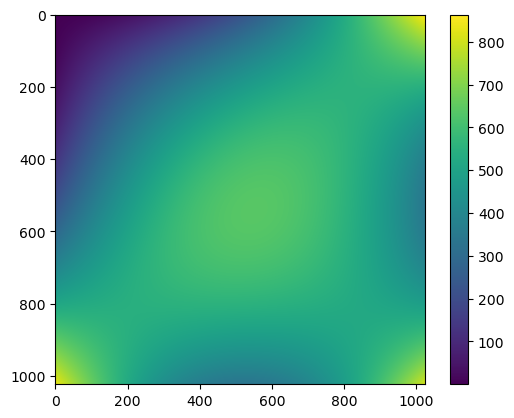

In [52]:
import matplotlib.pyplot as plt

plt.imshow(test_solp)
plt.colorbar()

### Save hyperparameters

Run the following cell.

Don't modify the following cell.

In [ ]:
# # # collect hyperparameters in a dictionary

# hyperparameter_dict = {

# 'metadata_directory':metadata_directory,
# 'fov_directory':fov_directory,
# 'output_directory':output_directory,
# 'metadata_file_name':metadata_file_name,
# 'is_train_column':is_train_column,
# 'train_val':train_val,
# 'default_metadata_file_target':default_metadata_file_target,
# 'default_metadata_file_exclude':default_metadata_file_exclude,
# 'metadata_from_file_name':metadata_from_file_name,
# 'metadata_default_separator':metadata_default_separator,
# 'metadata_default_date_position':metadata_default_date_position,
# 'metadata_default_date_format':metadata_default_date_format,
# 'metadata_default_reverse':metadata_default_reverse,
# 'channel_axis':channel_axis,
# 'fov_column_name':fov_column_name,
# 'null_value':null_value,
# 'plls_column_name':plls_column_name,
# 'low_percentile':low_percentile,
# 'high_percentile':high_percentile,
# 'bottom_perc_fract_column_name':bottom_perc_fract_column_name,
# 'top_perc_fract_column_name':top_perc_fract_column_name,
# 'mean_over_std_column_name':mean_over_std_column_name,
# 'ch_measurement_separator':ch_measurement_separator,
# 'save_file_name_separator':save_file_name_separator,
# 'project_name':project_name,
# 'save_csv_index':save_csv_index,
# 'metadata_date_format':metadata_date_format,
# 'metadata_savingword':metadata_savingword,
# 'metadata_file_suffix':metadata_file_suffix,
# 'hyperparameters_date_format':hyperparameters_date_format,
# 'hyperparameters_savingword':hyperparameters_savingword,
# 'hyperparameters_file_suffix':hyperparameters_file_suffix,
# 'secondary_output_directory':secondary_output_directory,
# 'exist_ok':exist_ok,
# 'plls_lowpass_thresholds':plls_lowpass_thresholds,
# 'bot_perc_lowpass_thresholds':bot_perc_lowpass_thresholds,
# 'top_perc_lowpass_thresholds':top_perc_lowpass_thresholds,
# 'mean_over_std_lowpass_thresholds':mean_over_std_lowpass_thresholds,
# 'plls_highpass_thresholds':plls_highpass_thresholds,
# 'bot_perc_highpass_thresholds':bot_perc_highpass_thresholds,
# 'top_perc_highpass_thresholds':top_perc_highpass_thresholds,
# 'mean_over_std_highpass_thresholds':mean_over_std_highpass_thresholds
# }

# # transform the hyperparameter_dict in a pandas series
# hyperparameter_series = pd.Series(hyperparameter_dict)

# # save hyperparamters
# hyperparameter_saving_name = f"{datetime.datetime.now().strftime(hyperparameters_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{hyperparameters_savingword}{save_file_name_separator}{hyperparameters_file_suffix}"
# hyperparameter_series.to_csv(os.path.join(secondary_output_directory,hyperparameter_saving_name), index=save_csv_index)

